# Auto-encodeurs avec Keras

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy
import scipy.interpolate
import tensorflow as tf
import tensorflow.keras as keras

## Chargement des données

Nous allons utiliser les données MNIST normalisées dans $[0, 1]$ (au lieu de $[0, 255]$). Habituellement, on préfère normaliser en centrant et en divisant par l'écart-type, mais celle-ci rend la visualisation plus simple.

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
nb_classes = 10
input_dim = 28 * 28
X_train = X_train.reshape(-1, input_dim).astype('float32')
X_test = X_test.reshape(-1, input_dim).astype('float32')

# Les pixels à 0 restent à 0.
X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
X_train.shape

(60000, 784)

## Auto-encodeurs simples

### Création de l'auto-encodeur

Concevons un auto-encodeur simple…

In [4]:
encoding_dim = 4
model = keras.models.Sequential()
model.add(keras.Input(shape=(input_dim,)))
model.add(keras.layers.Dense(encoding_dim, activation="leaky_relu"))
model.add(keras.layers.Dense(input_dim, activation="sigmoid"))
model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │         3,920 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,060 (27.58 KB)

 Trainable params: 7,060 (27.58 KB)

 Non-trainable params: 0 (0.00 B)

… et entraînons-le

In [5]:
model.fit(X_train, X_train,
          epochs=50,
          batch_size=256,
          validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1124 - val_loss: 0.0718
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0706 - val_loss: 0.0682
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0660 - val_loss: 0.0616
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0585 - val_loss: 0.0552
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0545 - val_loss: 0.0529
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0529 - val_loss: 0.0518
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0519 - val_loss: 0.0511
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0512 - val_loss: 0.0505
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0506 - val_loss: 0.0499
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0501 - val_loss: 0.0496
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0497 - val_loss: 0.0492
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

Passons maintenant à un plus complexe.

In [6]:
encoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(50,  activation="leaky_relu"),
     keras.layers.Dense(encoding_dim, activation="leaky_relu")],
    name="encoder")

decoder = keras.Sequential(
    [keras.layers.Input(shape=(encoding_dim,)),
     keras.layers.Dense(50,  activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(input_dim,
                        activation="sigmoid",
                        kernel_initializer="orthogonal")],
    name="decoder")

autoencoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)), encoder, decoder],
    name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mean_squared_error")


encoder.summary()
decoder.summary()
autoencoder.summary()



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 150)            │       117,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,154 (578.73 KB)

 Trainable params: 148,154 (578.73 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 4)              │       148,154 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       148,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,088 (1.13 MB)

 Trainable params: 297,088 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
encoding_dim = 4

In [8]:
autoencoder.fit(X_train, X_train,
          epochs=50,
          batch_size=256,
          validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0737 - val_loss: 0.0535
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0478 - val_loss: 0.0423
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0405 - val_loss: 0.0385
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0376 - val_loss: 0.0366
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0359 - val_loss: 0.0351
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0347 - val_loss: 0.0340
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0337 - val_loss: 0.0333
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0330 - val_loss: 0.0327
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0324 - val_loss: 0.0321
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0319 - val_loss: 0.0317
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0315 - val_loss: 0.0315
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

### Prédiction sur du bruit blanc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


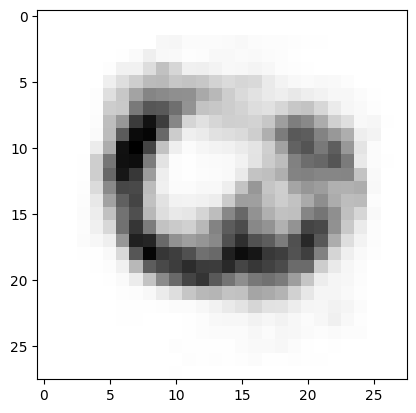

In [9]:
white_noise = numpy.random.random_sample((1, encoding_dim))
plt.imshow(decoder.predict(white_noise).reshape(28, 28), cmap="gray_r")
plt.show()

### Encodage des données de test

Encodons des données jamais vues dans le code calculé par l'encodeur

In [10]:
codes = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [11]:
codes.shape

(10000, 4)

### Calcul des centroïdes de chaque chiffre dans l'espace de codage

In [12]:
means = numpy.vstack([codes[y_test == i].mean(axis=0)
                      for i in range(nb_classes)])
stds = numpy.vstack([codes[y_test == i].std(axis=0)
                     for i in range(nb_classes)])

for i in range(10):
  dimension_stats = [f"{mean:5.2f}±{std:.2f}"
                     for mean, std in zip(means[i], stds[i])]
  print(f"Chiffre {i} {', '.join(dimension_stats)}")

Chiffre 0 17.67±5.69,  3.81±2.43,  6.17±4.88,  0.90±5.09
Chiffre 1 29.41±6.92, 46.71±7.26, 20.02±9.59, 16.23±4.18
Chiffre 2  9.59±5.04, 11.97±5.81, 17.63±6.11, 15.00±5.47
Chiffre 3 21.41±6.23, 15.66±4.27,  6.43±5.16, 11.90±4.52
Chiffre 4  0.25±3.21, 13.35±6.21,  9.01±6.94,  7.98±4.55
Chiffre 5 17.25±5.30, 10.64±4.03,  8.89±6.05,  3.89±4.71
Chiffre 6 11.45±6.31,  7.77±5.34,  4.23±4.69, 21.09±7.80
Chiffre 7  5.79±5.53, 24.24±7.01, 12.40±7.01,  3.66±3.62
Chiffre 8 12.24±4.66, 11.88±4.58,  9.83±6.45,  6.68±2.64
Chiffre 9  0.81±4.18, 16.00±6.11,  8.51±6.17,  7.07±2.81


Décodage des centroïdes par le décodeur :

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step


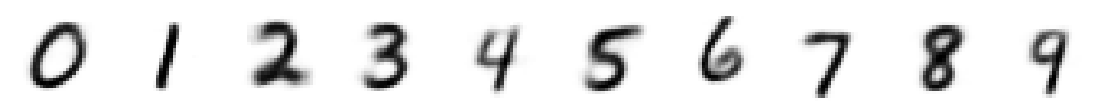

In [13]:
f, ax = plt.subplots(1, nb_classes, figsize=(1.4 * nb_classes, 2))

centroid_images = decoder.predict(means).reshape(-1, 28, 28)

for i, centroid_image in enumerate(centroid_images):
  ax[i].imshow(centroid_image, cmap="gray_r")
  ax[i].axis("off")
plt.show()

### Parcours de l'espace latent entre les centroïdes de deux chiffres

Maintenant que l'on sait où se trouvent les centroïdes de chaque chiffre, on peut parcourir l'espace latent entre deux d'entre eux.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


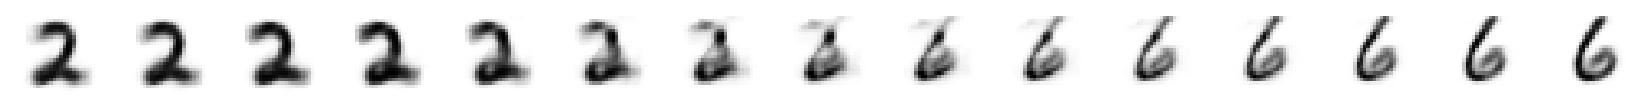

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


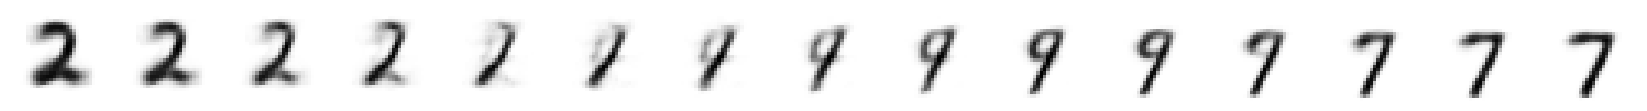

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


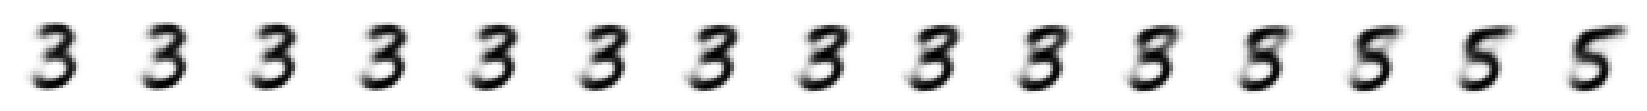

In [14]:
def latent_walk(start: int, end: int, n: int = 15):
  interpolator = scipy.interpolate.interp1d([0, n - 1],
                                            means[[start, end], :],
                                            axis=0)
  interpolated_codes = interpolator(range(n))
  interpolated_images = decoder.predict(interpolated_codes).reshape(-1, 28, 28)

  f, ax = plt.subplots(1, n, figsize=(n * 1.4, 2))
  for i, interpolated_image in enumerate(interpolated_images):
    ax[i].imshow(interpolated_image, cmap="gray_r")
    ax[i].axis("off")
  plt.show()


latent_walk(2, 6)
latent_walk(2, 7)
latent_walk(3, 5)

### Auto-encodage de toute la base de test

In [15]:
decoded_imgs = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [16]:
decoded_imgs_train = model.predict(X_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


### Visualisation

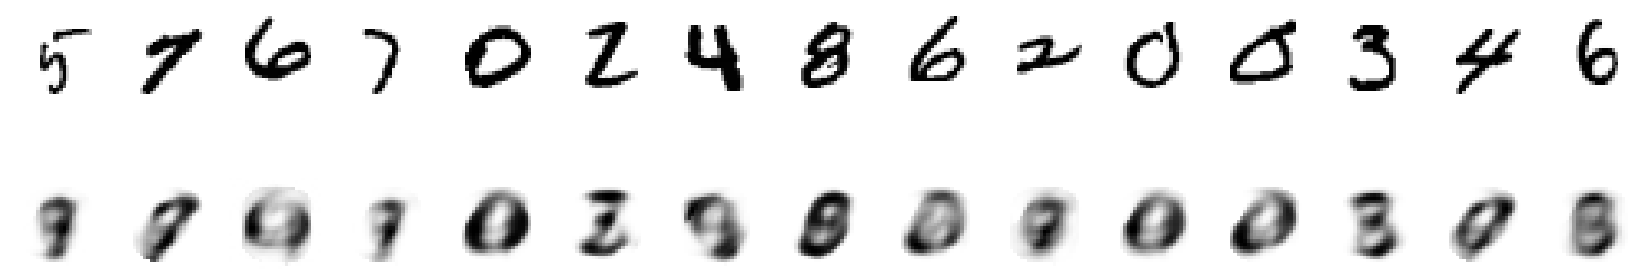

In [17]:
n = 15  # Nombre de chiffres à afficher

random_indexes = numpy.random.choice(decoded_imgs.shape[0],
                                     size=n,
                                     replace=False)

f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, random_index in enumerate(random_indexes):
    # L'original en haut
    ax[0, i].imshow(X_test[random_index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs[random_index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

Pires reconstructions sur le train


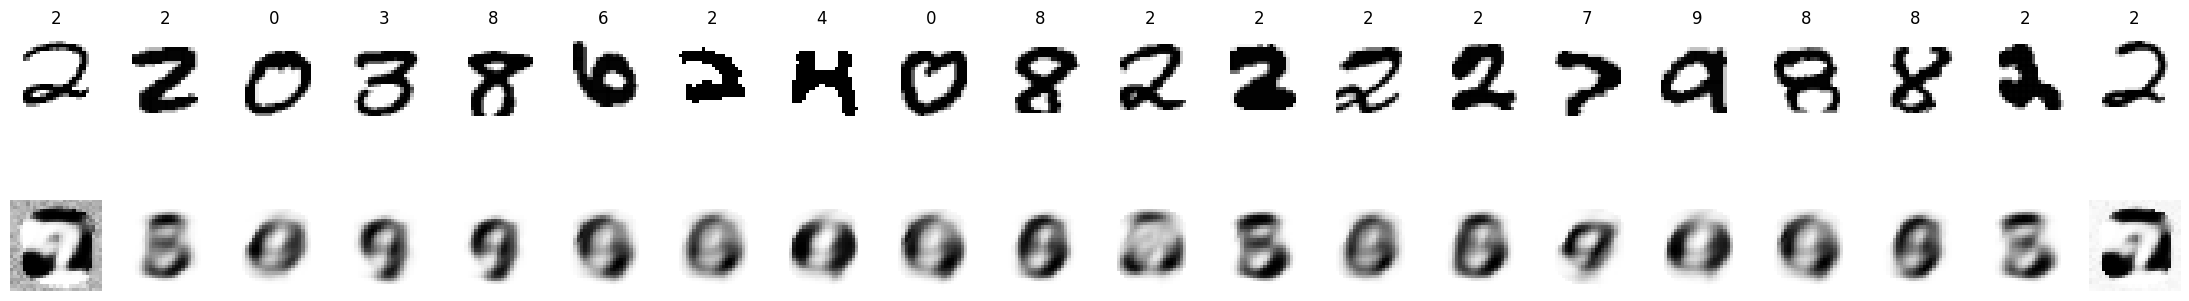

Pires reconstructions sur le test


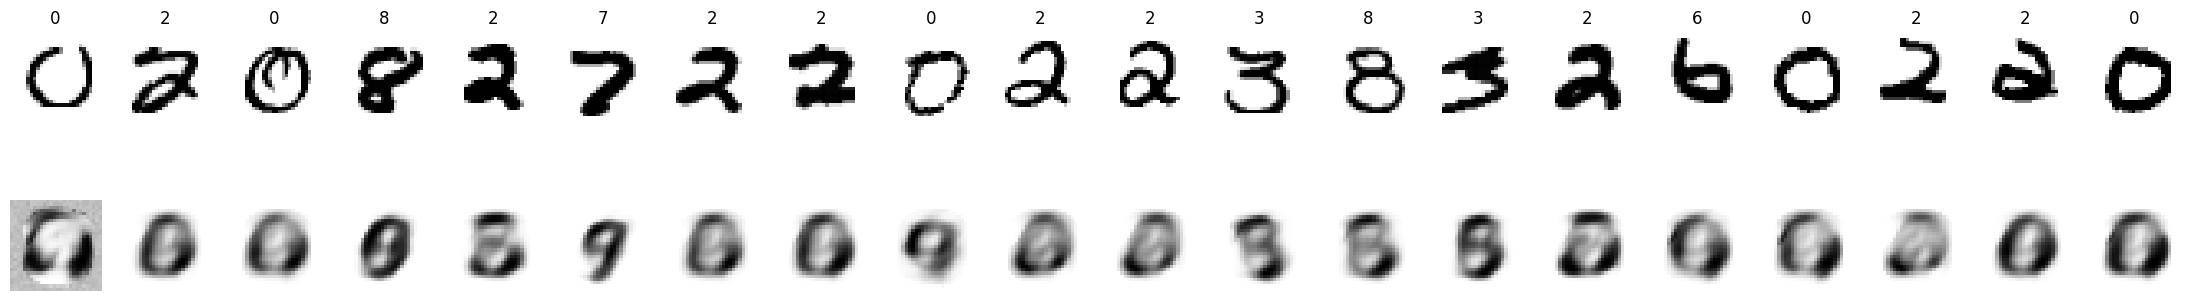

Meilleures reconstructions sur le train


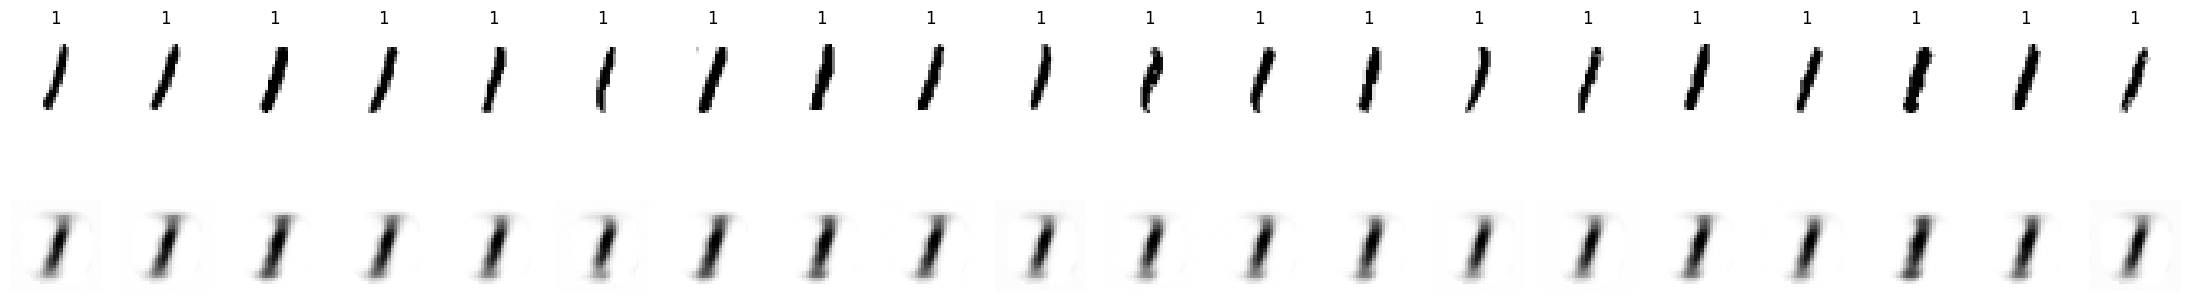

Meilleures reconstructions sur le test


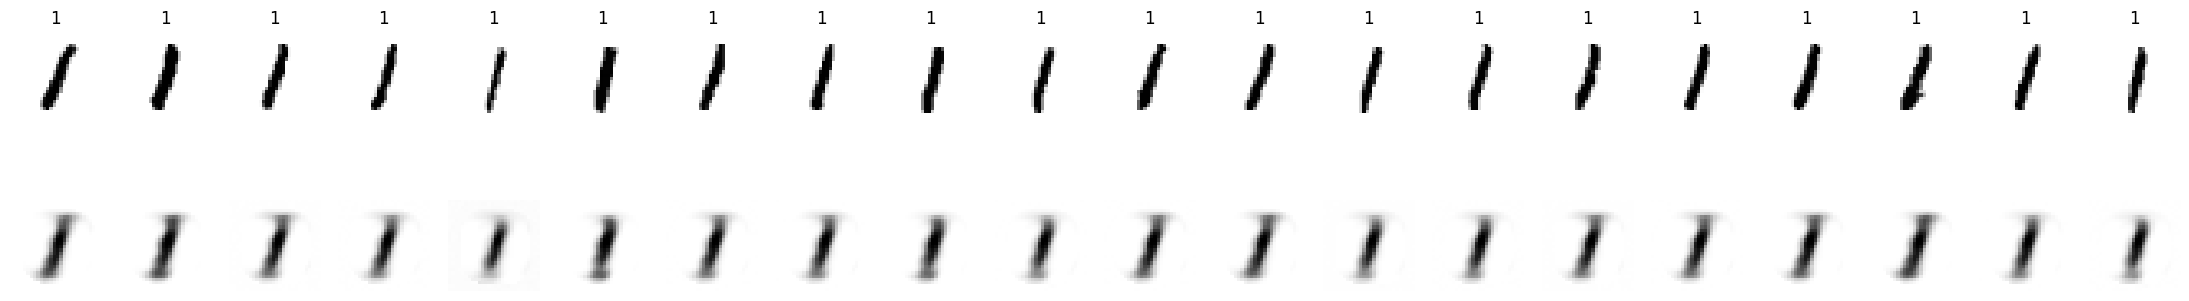

In [18]:
mse = keras.losses.MeanSquaredError(reduction="none")
test_anomalies = (-mse(decoded_imgs, X_test).numpy()).argsort()
train_anomalies = (-mse(decoded_imgs_train, X_train).numpy()).argsort()

n = 20

print("Pires reconstructions sur le train")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(train_anomalies[:n]):
    # L'original en haut
    ax[0, i].set_title(y_train[index])
    ax[0, i].imshow(X_train[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs_train[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()


print("Pires reconstructions sur le test")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(test_anomalies[:n]):
    # L'original en haut
    ax[0, i].set_title(y_test[index])
    ax[0, i].imshow(X_test[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

print("Meilleures reconstructions sur le train")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(train_anomalies[-n:]):
    # L'original en haut
    ax[0, i].set_title(y_train[index])
    ax[0, i].imshow(X_train[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs_train[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()


print("Meilleures reconstructions sur le test")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(test_anomalies[-n:]):
    # L'original en haut
    ax[0, i].set_title(y_test[index])
    ax[0, i].imshow(X_test[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

## Auto-encodeurs débruiteurs

### Application d'un bruit gaussien

In [19]:
noise_factor = 0.5
X_train_noisy = X_train + numpy.random.normal(0, noise_factor, X_train.shape)
X_test_noisy = X_test + numpy.random.normal(0, noise_factor, X_test.shape)

# On clip les valeurs pour éviter les valeurs au-dessus de 1 ou en dessous de 0
numpy.clip(X_train_noisy, 0, 1, out=X_train_noisy)
numpy.clip(X_test_noisy, 0, 1, out=X_test_noisy)

array([[0.36841864, 0.        , 0.28262179, ..., 0.        , 0.57639746,
        0.        ],
       [0.58088189, 0.65074144, 0.        , ..., 0.        , 0.        ,
        0.07619061],
       [0.        , 0.        , 0.25994537, ..., 0.        , 0.        ,
        0.43225793],
       ...,
       [0.        , 0.49939678, 0.        , ..., 0.        , 0.76038819,
        0.        ],
       [0.10206268, 0.8194483 , 0.        , ..., 0.05719783, 0.61525463,
        0.49491589],
       [1.        , 0.39797202, 0.3657956 , ..., 0.        , 0.0450838 ,
        0.        ]])

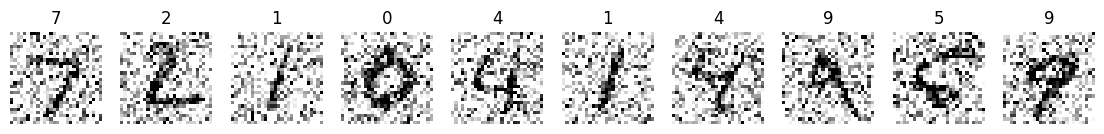

In [20]:
n = 10
f, ax = plt.subplots(1, n, figsize=(n * 1.4, 2))
for i in range(n):
    ax[i].imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax[i].set_title(y_test[i])
    ax[i].axis("off")
plt.show()

### Création de l'auto-encodeur débruiteur

In [21]:
encoding_dim = 4
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(input_dim,)))
model.add(keras.layers.Dense(encoding_dim, activation="relu"))
model.add(keras.layers.Dense(input_dim, activation="sigmoid"))
model.compile(optimizer="adam", loss="mean_squared_error")

### Apprentissage

In [22]:
model.fit(X_train_noisy, X_train,
          epochs=50,
          batch_size=256,
          validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0949 - val_loss: 0.0681
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0681 - val_loss: 0.0667
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0653 - val_loss: 0.0618
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0595 - val_loss: 0.0571
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0563 - val_loss: 0.0550
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0546 - val_loss: 0.0537
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0537 - val_loss: 0.0532
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0532 - val_loss: 0.0529
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0529 - val_loss: 0.0525
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0526 - val_loss: 0.0522
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0522 - val_loss: 0.0520
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

### Auto-encodage de toute la base de test

Auto-encodez les images de test et stockez les images obtenues dans la variable `decoded_imgs`

In [23]:
decoded_imgs = model.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Visualisation

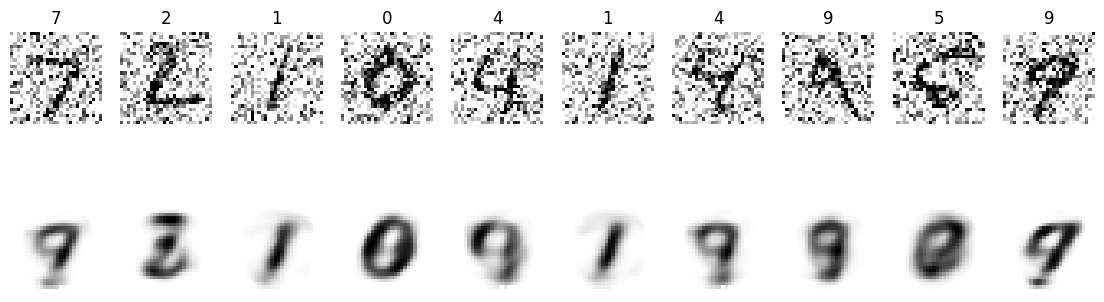

In [24]:
n = 10
f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i in range(n):
    # L'original en haut
    ax[0, i].imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax[0, i].set_title(str(y_test[i]))
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs[i].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

### Auto-encodeurs convolutifs débruiteurs

Il faut d'abord redimensionner en $(\text{batch} \times \text{largeur} \times \text{hauteur} \times \text{canaux})$ pour utiliser Keras.

In [25]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train_noisy = X_train_noisy.reshape(-1, 28, 28, 1)
X_test_noisy = X_test_noisy.reshape(-1, 28, 28, 1)

### Création de l'auto-encodeur convolutif débruiteur

In [26]:
encoding_dim = 4

model = keras.models.Sequential()
# Encodage
model.add(keras.Input(shape=X_train.shape[1:]))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(1, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(encoding_dim))

# Décodage
model.add(keras.layers.Dense(49))
model.add(keras.layers.Reshape((7, 7, 1)))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2DTranspose(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(32, (3, 3), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2DTranspose(32, (2, 2), (2, 2), activation="leaky_relu", padding="same"))
model.add(keras.layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same"))

model.compile(optimizer=keras.optimizers.Adam(0.0001), loss="mean_squared_error")

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 1)        │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 49)             │           245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         4,128 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,128 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,671 (143.25 KB)

 Trainable params: 36,671 (143.25 KB)

 Non-trainable params: 0 (0.00 B)

### Apprentissage

In [27]:
model.fit(X_train_noisy, X_train,
          epochs=100,
          batch_size=128,
          validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.1140 - val_loss: 0.0714
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0689 - val_loss: 0.0673
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0667 - val_loss: 0.0644
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0617 - val_loss: 0.0589
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0572 - val_loss: 0.0557
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0547 - val_loss: 0.0538
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0531 - val_loss: 0.0524
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0517 - val_loss: 0.0514
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0505 - val_loss: 0.0503
Epoch 10/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0495 - val_loss: 0.0493
Epoch 11/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0487 - val_loss: 0.0485
Epoch 12/100
375/375 ━━━━━━━━━━━━━

### Visualisation

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


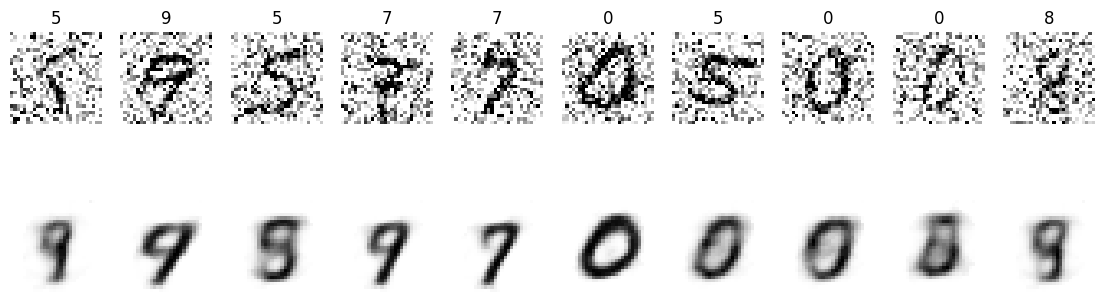

In [28]:
decoded_imgs = model.predict(X_test_noisy).reshape(-1, 28, 28)

n = 10
f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

for i, random_index in enumerate(random_indexes):
    # L'original en haut
    ax[0, i].set_title(str(y_test[random_index]))
    ax[0, i].imshow(X_test_noisy[random_index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs[random_index], cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

### Visualisation sur des images non bruitées

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


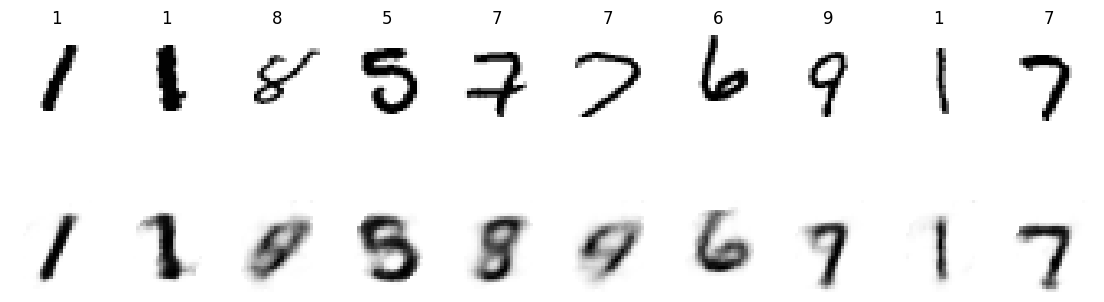

In [29]:
decoded_imgs = model.predict(X_test).reshape(-1, 28, 28)

n = 10
f, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

for i, random_index in enumerate(random_indexes):
    # L'original en haut
    ax[0, i].set_title(str(y_test[random_index]))
    ax[0, i].imshow(X_test[random_index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(decoded_imgs[random_index], cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

## Auto-encodeurs variationnels

Pour les VAEs, la méthode d'apprentissage est moins simple (à cause de l'[astuce de re-paramétrisation](https://stats.stackexchange.com/questions/199605/how-does-the-reparameterization-trick-for-vaes-work-and-why-is-it-important)). Les mainteneurs de Keras suggèrent d'utiliser le code suivant :

In [30]:
class Sampling(keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [31]:
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(16, activation="relu")(x)
z_mean = keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = keras.layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = keras.layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = keras.layers.Reshape((7, 7, 64))(x)
x = keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = keras.layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [34]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(X_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - kl_loss: 2.1338 - loss: 216.8876 - reconstruction_loss: 214.7538
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 2.8970 - loss: 191.9769 - reconstruction_loss: 189.0798
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 2.9557 - loss: 186.8828 - reconstruction_loss: 183.9272
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 4.7669 - loss: 173.6348 - reconstruction_loss: 168.8680
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.5801 - loss: 165.9784 - reconstruction_loss: 160.3982
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 5.7995 - loss: 163.1501 - reconstruction_loss: 157.3506
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.9081 - loss: 161.4380 - reconstruction_loss: 155.5297
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 6.0072 - loss: 160.1506 - reconstruction_loss: 154.1434
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms

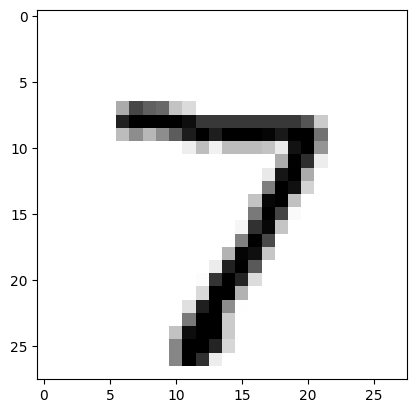

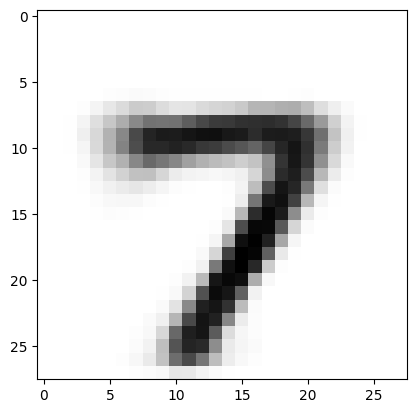

In [35]:
def auto_encode_example(example: numpy.ndarray) -> None:
  x_z_mean, x_z_log_var, x_z = vae.encoder(example[None, ...])
  decoded = vae.decoder(x_z).numpy().squeeze()
  plt.imshow(example.squeeze(), cmap="gray_r")
  plt.show()
  plt.imshow(decoded, cmap="gray_r")
  plt.show()


auto_encode_example(X_test[0])